[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Assembling the Transformer

In notebook 1 the transformer was a sealed black box.  Now most of its contents are on the table: scaled dot product attention, learned projections split into multiple heads, and positional encoding.  This notebook adds the remaining parts — a position-wise feed-forward network, and residual connections with layer normalization — assembles everything into our own transformer encoder, and closes the loop of the whole module: we train the from-scratch model on the same IMDb data as the black box of notebook 1 and check that it performs the same.  Nothing in the box will be left unexplained.

Here is the whole thing we are about to assemble. It is an *encoder-only* classifier — simpler than the original encoder–decoder transformer, whose second (decoder) column is needed only when the output is itself a sequence, as in translation. Our task maps a sequence to a single label, so one column suffices. The next cell draws it:

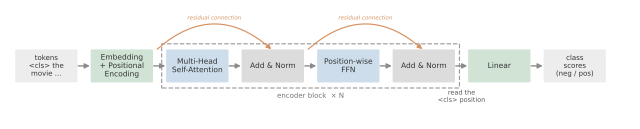

In [4]:

# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

# a map of the architecture we are about to build: an encoder-only
# classifier (simpler than the original encoder-decoder transformer).
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

W, H, GAP = 2.15, 1.1, 0.55
STEP = W + GAP

def cx(i):
    return i * STEP

# faded palette: two soft accents (blue = the block's learned sublayers,
# green = the embedding / linear boundary maps) plus two grays (wrappers, I/O)
BLUE, GREEN, NORM, IO = '#cdddec', '#d0e3d4', '#dcdcdc', '#ededed'
ARC = '#d79161'   # muted orange for the residual paths
TX = '#333333'

def box(ax, i, text, color, fs=7.5):
    x = cx(i)
    ax.add_patch(FancyBboxPatch((x - W/2, -H/2), W, H,
                                boxstyle='round,pad=0.04',
                                facecolor=color, edgecolor='none'))
    ax.text(x, 0, text, ha='center', va='center', color=TX, fontsize=fs)

def flow(ax, i, j):
    # edge-to-edge arrow along the spine (in the gap, not into the boxes)
    ax.annotate('', xy=(cx(j) - W/2, 0), xytext=(cx(i) + W/2, 0),
                arrowprops=dict(arrowstyle='-|>', color='0.55', lw=1.4))

def residual(ax, i_in, i_norm):
    # arc bypassing a sublayer, from just before it to the Add & Norm after it
    x0 = cx(i_in) + W/2 + GAP*0.25
    x1 = cx(i_norm)
    ax.annotate('', xy=(x1, H/2), xytext=(x0, H/2),
                arrowprops=dict(arrowstyle='-|>', color=ARC, lw=1.2,
                                connectionstyle='arc3,rad=-0.45'))
    ax.text((x0 + x1)/2, 1.62, 'residual connection', ha='center',
            va='bottom', fontsize=5.5, style='italic', color=ARC)

fig, ax = plt.subplots(figsize=(9, 3.7))

box(ax, 0, 'tokens\n<cls> the\nmovie …', IO, fs=7)
box(ax, 1, 'Embedding\n+ Positional\nEncoding', GREEN)
box(ax, 2, 'Multi-Head\nSelf-Attention', BLUE)
box(ax, 3, 'Add & Norm', NORM)
box(ax, 4, 'Position-wise\nFFN', BLUE)
box(ax, 5, 'Add & Norm', NORM)
box(ax, 6, 'Linear', GREEN)
box(ax, 7, 'class\nscores\n(neg / pos)', IO, fs=7)

for i in range(7):
    flow(ax, i, i + 1)

# dashed container around the repeated encoder block (boxes 2..5)
left = cx(2) - W/2 - 0.18
right = cx(5) + W/2 + 0.18
ax.add_patch(FancyBboxPatch((left, -H/2 - 0.22), right - left, H + 0.44,
             boxstyle='round,pad=0.02', facecolor='none', edgecolor='0.62',
             linestyle='--', lw=1.2))
ax.text((left + right)/2, -H/2 - 0.4, 'encoder block  × N', ha='center',
        va='top', fontsize=7, color='0.45')

residual(ax, 1, 3)     # X + Self-Attention(X)
residual(ax, 3, 5)     # + FFN(...)

ax.text((cx(5) + cx(6))/2, -H/2 - 0.3, 'read the\n<cls> position',
        ha='center', va='top', fontsize=6.5, color='#555555')

ax.set_xlim(-1.4, cx(7) + W/2 + 1.0)
ax.set_ylim(-2.0, 2.1)
ax.axis('off')
ax.set_aspect('equal')
plt.tight_layout();

The core is a stack of identical **encoder blocks**. Each block has two sublayers — multi-head self-attention (which we already have) and a small position-wise MLP (which we build next) — and around each sublayer sits the same wrapper: a residual connection followed by layer normalization, the *Add & Norm* boxes (the orange arrows are the residual paths). At the input (left) token embeddings plus positional encodings feed in; at the output (right) we read out the single `<cls>` position and a linear layer turns that vector into the two class scores.

First, the pieces we carry over from the previous notebooks:

In [1]:
import collections
import math
import os
import re
import tarfile
import time
import urllib.request

import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
from matplotlib import pyplot as plt


def attention(Q, K, V):
    """Scaled dot product attention (notebook 3); broadcasts over any
    leading batch axes."""
    d = Q.shape[-1]
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d)
    weights = F.softmax(scores, dim=-1)
    return weights @ V, weights


class MultiHeadAttention(nn.Module):
    """Multi-head attention with learned projections (notebook 4)."""
    def __init__(self, num_hiddens, num_heads, bias=True):
        super().__init__()
        self.num_heads = num_heads
        self.W_q = nn.Linear(num_hiddens, num_hiddens, bias=bias)
        self.W_k = nn.Linear(num_hiddens, num_hiddens, bias=bias)
        self.W_v = nn.Linear(num_hiddens, num_hiddens, bias=bias)
        self.W_o = nn.Linear(num_hiddens, num_hiddens, bias=bias)

    def split_heads(self, X):
        b, seq, _ = X.shape
        return X.reshape(b, seq, self.num_heads, -1).transpose(1, 2)

    def merge_heads(self, X):
        b, h, seq, d_head = X.shape
        return X.transpose(1, 2).reshape(b, seq, h * d_head)

    def forward(self, queries, keys, values):
        Q = self.split_heads(self.W_q(queries))   # (batch, heads, seq, d_head)
        K = self.split_heads(self.W_k(keys))
        V = self.split_heads(self.W_v(values))
        output, self.attention_weights = attention(Q, K, V)
        return self.W_o(self.merge_heads(output))


class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding (notebook 4)."""
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float()
                             * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, X):
        return X + self.pe[:, :X.size(1), :]

## The position-wise feed-forward network

Attention *moves* information between positions, but notice what it does to each value on arrival: nothing except a weighted average and a linear map.  Averages of linear maps are still linear — a stack of pure attention layers could never compute anything nonlinear in the values.  The second sublayer supplies the nonlinearity: a two-layer MLP applied to each position's vector *independently*, with the same weights at every position.  This is why it is called *position-wise*: it transforms what each position holds, without looking sideways.  The division of labor within a block is clean — attention mixes across positions, the FFN computes within them.

The hidden width `ffn_num_hiddens` is the black box's `dim_feedforward` hyperparameter — the last of the mystery hyperparameters from notebook 1.  It is conventionally larger than the model dimension (4$\times$ in the original transformer), giving each position room to compute before projecting back down.

In [2]:
class PositionWiseFFN(nn.Module):
    """The same two-layer MLP applied at every position."""
    def __init__(self, num_hiddens, ffn_num_hiddens):
        super().__init__()
        self.dense1 = nn.Linear(num_hiddens, ffn_num_hiddens)
        self.relu = nn.ReLU()
        self.dense2 = nn.Linear(ffn_num_hiddens, num_hiddens)

    def forward(self, X):
        # X: (batch, positions, num_hiddens); nn.Linear acts on the last
        # dimension, i.e., on each position separately
        return self.dense2(self.relu(self.dense1(X)))

Because the same MLP acts at every position, identical inputs at different positions give identical outputs:

In [3]:
ffn = PositionWiseFFN(4, 8)
ffn.eval()
ffn(torch.ones((2, 3, 4)))[0]

tensor([[-0.4951, -0.2165,  0.4534,  0.0048],
        [-0.4951, -0.2165,  0.4534,  0.0048],
        [-0.4951, -0.2165,  0.4534,  0.0048]], grad_fn=<SelectBackward0>)

## Residual connections and layer normalization

One wrapper is left: the *Add & norm* boxes in the figure.  It is easy to read past as plumbing, but a transformer without it does not train, and its two halves solve two unrelated problems.  The **Add** is what makes a deep *stack* of blocks optimizable at all; the **norm** keeps the numbers each sublayer sees at a workable scale.  Take them in that order.

### Add: the residual connection

Think about what a stack of $N$ blocks does to one token's vector.  Block 1 replaces it, block 2 replaces the replacement, and so on: after $N$ blocks the original embedding has been through $N$ wholesale rewrites, and anything that survives to the top survived by being re-encoded at every level.  Gradients make the same trip in reverse.  This is the arrangement that stops working as $N$ grows — and not because the network runs out of capacity.

Here is the sharpest form of the problem.  Suppose a two-block model works well and we would like to try four.  If the two extra blocks each computed the *identity*, the four-block model would compute exactly what the two-block one does and score exactly the same.  A solution at least as good as the shallow model's therefore **provably exists** in the deeper model's parameter space.  Yet deeper models routinely do worse — worse on the *training* set, where overfitting is no excuse.  Gradient descent fails to find a solution we can write down by hand.

That points at the fix.  The trouble is that the identity is an awkward function for a sublayer to compute: multi-head attention, with its four learned projection matrices, has to *construct* $\mathbf{x} \mapsto \mathbf{x}$ out of its weights, and a random initialization is nowhere near it.  So change what the sublayer is asked to produce.  Let it compute the *difference* between what the representation should be and what it already is — the **residual** — and add the input back:

$$\mathbf{x} \;\longmapsto\; \mathbf{x} + \textrm{sublayer}(\mathbf{x})$$

The set of functions a block can express is unchanged: anything you could write as $f(\mathbf{x})$ you can write as $\mathbf{x} + g(\mathbf{x})$ with $g = f - \mathbf{x}$.  What changes is which function is *easy*.  The identity is now $\textrm{sublayer}(\mathbf{x}) = 0$, and zero is where small initialization starts and where weight decay pulls.  A sublayer with nothing useful to contribute gets out of the way for free, and every sublayer's job becomes a *correction* to the representation rather than a replacement for it.

This is also why every sublayer in a transformer preserves the model dimension $d_{\textrm{model}}$: the addition demands matching shapes.  That constraint is not an aesthetic choice, it is the price of the residual path.

### Why the gradient survives

There is a second reading of the same equation, and for deep stacks it is the more important one.

Write $\mathbf{x}_{l+1} = f_l(\mathbf{x}_l)$ for a plain stack of $L$ sublayers.  The chain rule gives

$$\frac{\partial \mathcal{L}}{\partial \mathbf{x}_0}
= \frac{\partial \mathcal{L}}{\partial \mathbf{x}_L}
  \prod_{l=0}^{L-1} \frac{\partial f_l}{\partial \mathbf{x}_l},$$

a product of $L$ Jacobians.  If each one scales its input by a typical factor $\sigma$, the product scales by $\sigma^L$ — exponential in depth.  For $\sigma = 0.9$ and $L = 24$ that is a factor of about $10^{-2}$; for $\sigma = 0.5$ it is $10^{-8}$.  Nothing holds $\sigma$ at exactly 1: initialization can set it approximately, at the start, before training moves the weights wherever it likes.

Now the residual version, $\mathbf{x}_{l+1} = \mathbf{x}_l + g_l(\mathbf{x}_l)$.  Differentiating, and writing $J_l = \partial g_l / \partial \mathbf{x}_l$,

$$\frac{\partial \mathbf{x}_{l+1}}{\partial \mathbf{x}_l} = \mathbf{I} + J_l,
\qquad\textrm{so}\qquad
\prod_{l=0}^{L-1}\left(\mathbf{I} + J_l\right)
= \mathbf{I} \;+\; \sum_l J_l \;+\; \sum_{l < m} J_m J_l \;+\; \cdots$$

**The leading term is the identity, and it is there whatever the weights do.**  Every other term contains at least one Jacobian and can shrink toward zero; that one cannot, because it contains no weights at all.  The gradient therefore always has a route from the loss back to sublayer $l$ with gain exactly 1, and the failure mode changes character: no longer "the signal decays by construction", but "the signal decays only if the learned terms actively cancel it".

We can watch this happen.  The cell below stacks $L$ copies of the position-wise FFN we just built — once plainly, once with the residual — pushes one batch through, backpropagates, and records the norm of the gradient arriving at each sublayer's input.

In [3]:
def gradient_by_depth(residual, depth=24, num_hiddens=64, seq=16, batch=32,
                      seed=0):
    """Norm of the gradient arriving at the input of each sublayer in a stack."""
    torch.manual_seed(seed)
    sublayers = nn.ModuleList([PositionWiseFFN(num_hiddens, 4 * num_hiddens)
                               for _ in range(depth)])
    X = torch.randn(batch, seq, num_hiddens, requires_grad=True)
    entering = []
    for sublayer in sublayers:
        X.retain_grad()
        entering.append(X)
        X = X + sublayer(X) if residual else sublayer(X)
    # a random covector, so the gradient at the top is not artificially uniform
    (X * torch.randn_like(X)).sum().backward()
    return [x.grad.norm().item() for x in entering]


plain, skip = gradient_by_depth(residual=False), gradient_by_depth(residual=True)
print(f'plain stack     top {plain[-1]:9.2e}   bottom {plain[0]:9.2e}')
print(f'residual stack  top {skip[-1]:9.2e}   bottom {skip[0]:9.2e}')

fig, ax = plt.subplots(figsize=(5.5, 3.4))
ax.semilogy(plain, 'o-', color='C0', markersize=3, label='plain stack')
ax.semilogy(skip, 's-', color='C3', markersize=3, label='residual stack')
ax.set_xlabel('sublayer (0 is closest to the input)')
ax.set_ylabel('norm of the gradient entering it')
ax.legend()
fig.tight_layout();

NameError: name 'torch' is not defined

Note the logarithmic axis: the plain stack's curve is close to a straight line on it, and a straight line on a log axis is exponential decay.  Over twenty-four sublayers the gradient falls by some fourteen orders of magnitude, so by the time it reaches the bottom there is nothing left — whatever learning rate suits the top of the stack leaves the bottom frozen.  The residual curve is nearly flat, and if anything drifts *upward* toward the input, because each sublayer adds its own contribution to a gradient that is already passing through undiminished.  That is the $\mathbf{I}$ in the expansion above, made visible.

It is worth adopting the mental picture this suggests, because it is how people talk about transformers.  The chain of additions running from the embedding to the output is a single **residual stream**: each sublayer *reads* the stream, computes something, and *writes its result back by addition*.  Nothing is ever overwritten.  A block's contribution is one term in a sum, which is why it is meaningful to ask what an individual attention head "adds" to a representation, and why removing a single head from a trained model usually degrades it rather than breaking it.

### Norm: layer normalization

Solving one problem has created another.  Every sublayer now adds to the residual stream, so the stream's magnitude grows as we go up, and each sublayer receives whatever scale the layers below happen to be producing at that moment in training.  Both sublayers care.  Attention is the clearest case: scale the queries and keys by 10 and the pre-softmax scores scale by 100, turning a distribution spread across the sequence into a spike on a single position — the same sensitivity that made the $1/\sqrt{d}$ factor necessary in notebook 3, now driven by depth rather than by dimension.  The FFN has a useful operating range too, and a stack whose activations drift by orders of magnitude cannot be served by one learning rate.

The remedy is the one you already apply to a dataset before training on it: standardize.  **Layer normalization** standardizes a single position's vector, using statistics computed from that vector alone:

$$\textrm{LN}(\mathbf{x}) = \boldsymbol{\gamma} \odot
\frac{\mathbf{x} - \mu}{\sqrt{\sigma^2 + \epsilon}} + \boldsymbol{\beta},
\qquad
\mu = \frac{1}{d}\sum_{i=1}^{d} x_i,
\qquad
\sigma^2 = \frac{1}{d}\sum_{i=1}^{d} (x_i - \mu)^2$$

with $d = d_{\textrm{model}}$, $\odot$ elementwise multiplication, and $\epsilon$ a small constant guarding against division by zero.

The first part is plain standardization.  The interesting part is $\boldsymbol{\gamma}$ and $\boldsymbol{\beta}$: a learned scale and shift applied *after* it, one entry per feature.  Why undo the work you just did?  Because forcing every vector to mean 0 and variance 1 is a strong constraint and not always the right one — with $\boldsymbol{\gamma}$ and $\boldsymbol{\beta}$ the layer can settle on whatever scale suits it, up to and including recovering its input exactly.  What normalization removes is not the freedom, it is the *coupling*: the scale is now set by two parameters trained directly for the purpose, instead of emerging uncontrolled from the product of everything below.

That leaves the question of which values get averaged together.  Collect a batch of activations into a matrix with one row per token — every position of every sequence — and one column per feature.  There are two natural directions in which to standardize it:

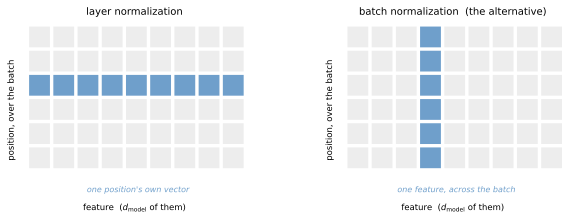

In [2]:
def normalization_axis_figure():
    """A batch of activations as a (tokens x features) matrix: layer norm
    standardizes a row, batch normalization a column."""
    n_tokens, n_features = 6, 9
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
    panels = [('layer normalization', 'row', "one position's own vector"),
              ('batch normalization  (the alternative)', 'column',
               'one feature, across the batch')]
    for ax, (title, kind, note) in zip(axes, panels):
        for i in range(n_tokens):
            for j in range(n_features):
                shaded = ((kind == 'row' and i == 2) or
                          (kind == 'column' and j == 3))
                ax.add_patch(plt.Rectangle(
                    (j, n_tokens - 1 - i), 0.86, 0.86, edgecolor='none',
                    facecolor='#6f9fcb' if shaded else '#ededed'))
        ax.set_xlim(-0.4, n_features + 0.1)
        ax.set_ylim(-1.3, n_tokens + 0.1)
        ax.set_xlabel(r'feature  ($d_{\mathrm{model}}$ of them)', fontsize=8.5)
        ax.set_ylabel('position, over the batch', fontsize=8.5)
        ax.set_title(title, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_aspect('equal')
        ax.text(n_features / 2, -0.9, note, ha='center', va='center',
                fontsize=8, style='italic', color='#6f9fcb')
        for spine in ax.spines.values():
            spine.set_visible(False)
    fig.tight_layout()


normalization_axis_figure()

**Layer normalization takes a row**: one position, across its own $d_{\textrm{model}}$ features.  The alternative, **batch normalization**, takes a column: one feature, across every token in the batch.  Same matrix, perpendicular slices — and the difference is not cosmetic.

A column crosses examples, so its statistics depend on what else happened to be in the batch, and for a transformer over text that is a bad trade in four separate ways.  Sequences have different lengths and are padded, so the values sharing a column are not all comparable quantities and the padding pollutes the statistics.  The number of real tokens per batch varies with those lengths, so the quality of the estimate varies with it.  Generation runs one sequence at a time, often one token at a time, and a batch of one has zero variance.  And since batch statistics are unavailable at prediction time, batch normalization has to keep running estimates and behave *differently* in training and evaluation — a permanent source of quiet bugs.

Layer normalization has none of these properties.  Its statistics come from one vector, so the function it computes is identical for a batch of one and a batch of a thousand, identical during training and during generation, and independent of padding entirely.  There is no running state to maintain.  (Batch normalization is not a bad idea — it is the standard choice in convolutional networks, where a channel's statistics really are pooled over a fixed spatial grid, and the CNN module takes it up from that side.  It is a bad fit *here*.)

Written out, layer normalization is four lines:

In [ ]:
class LayerNorm(nn.Module):
    """Standardize each position's vector across its own features, then apply
    a learned scale and shift.  This is PyTorch's nn.LayerNorm, written out."""
    def __init__(self, num_hiddens, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(num_hiddens))     # scale
        self.beta = nn.Parameter(torch.zeros(num_hiddens))     # shift

    def forward(self, X):
        # statistics over the last axis only: one mean and one variance per
        # position, each computed from that position's own vector
        mean = X.mean(dim=-1, keepdim=True)
        var = X.var(dim=-1, keepdim=True, unbiased=False)
        return self.gamma * (X - mean) / torch.sqrt(var + self.eps) + self.beta


torch.manual_seed(0)
X = 3 + 2 * torch.randn(2, 5, 24)      # (batch, positions, features), off-scale
ours, theirs = LayerNorm(24), nn.LayerNorm(24)
with torch.no_grad():                  # give both the same learned gamma, beta
    gamma, beta = torch.randn(24), torch.randn(24)
    ours.gamma.copy_(gamma); theirs.weight.copy_(gamma)
    ours.beta.copy_(beta);   theirs.bias.copy_(beta)
print('max difference from nn.LayerNorm:',
      (ours(X) - theirs(X)).abs().max().item())
assert torch.allclose(ours(X), theirs(X), atol=1e-6)


def row(v):
    return ' '.join(f'{x:6.2f}' for x in v)

Z = LayerNorm(24)(X)          # gamma = 1, beta = 0: standardization and nothing else
print('\nper-position statistics, sequence 0 of the batch:')
print('  in    mean', row(X.mean(-1)[0]), '  std', row(X.std(-1, unbiased=False)[0]))
print('  out   mean', row(Z.mean(-1)[0]), '  std', row(Z.std(-1, unbiased=False)[0]))

max difference from nn.LayerNorm: 5.960464477539062e-07

per-position statistics, sequence 0 of the batch:
  in    mean   2.75   3.36   3.70   2.83   2.59   std   2.04   1.77   2.43   1.87   2.02
  out   mean  -0.00  -0.00  -0.00  -0.00   0.00   std   1.00   1.00   1.00   1.00   1.00


Every position leaves with mean 0 and variance 1 regardless of what it arrived with and — the point of the exercise — regardless of its neighbours in the batch.  From here on we use PyTorch's `nn.LayerNorm`, which is the same function with a faster kernel.

Two notes before we assemble.  The learned $\boldsymbol{\gamma}$ and $\boldsymbol{\beta}$ are ordinary parameters and there is no other state — no buffers, no running averages, nothing that `model.train()` and `model.eval()` switch between.  And normalization is not free: a mean, a variance and two elementwise operations per position, at every sublayer of every block.  That cost is why recent models economize on it with **RMSNorm**, which drops the mean subtraction (dividing by the root-mean-square alone) and works about as well.

### Add & norm

With both halves understood, the wrapper is three lines.  The original transformer applies the normalization *after* the residual addition — $\textrm{LayerNorm}(\mathbf{x} + \textrm{sublayer}(\mathbf{x}))$ — which is what we implement here; exercise 2 takes up the modern alternative.

In [5]:
class AddNorm(nn.Module):
    """Residual connection followed by layer normalization."""
    def __init__(self, num_hiddens, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(num_hiddens)

    def forward(self, X, Y):
        # X: the sublayer's input; Y: the sublayer's output
        return self.ln(self.dropout(Y) + X)

Dropout on the sublayer output is the transformer's regularizer of choice; the residual path is never dropped.

## The encoder block

The block is now a few lines: self-attention (queries, keys, and values all the block's input), then the FFN, each wrapped in Add & norm.  Note that nothing in the block changes the tensor's shape — blocks are stackable by construction.

In [6]:
class TransformerEncoderBlock(nn.Module):
    """One transformer encoder block: self-attention + position-wise FFN."""
    def __init__(self, num_hiddens, ffn_num_hiddens, num_heads, dropout):
        super().__init__()
        self.attention = MultiHeadAttention(num_hiddens, num_heads)
        self.addnorm1 = AddNorm(num_hiddens, dropout)
        self.ffn = PositionWiseFFN(num_hiddens, ffn_num_hiddens)
        self.addnorm2 = AddNorm(num_hiddens, dropout)

    def forward(self, X):
        Y = self.addnorm1(X, self.attention(X, X, X))
        return self.addnorm2(Y, self.ffn(Y))

X = torch.randn(2, 100, 24)
encoder_blk = TransformerEncoderBlock(24, 48, 8, 0.5)
encoder_blk.eval()
print(encoder_blk(X).shape)
assert encoder_blk(X).shape == X.shape

torch.Size([2, 100, 24])


## Verification: our block against `nn.TransformerEncoderLayer`

The moment of truth for the whole module.  `nn.TransformerEncoderLayer` — the layer we stacked inside the black box in notebook 1 — should contain *exactly* the parts we just assembled: an `nn.MultiheadAttention`, two linear layers forming the FFN, and two layer norms applied after residual additions.  We copy our block's weights into the library layer, feed both the same input, and demand agreement to floating-point precision:

In [7]:
torch.manual_seed(0)
num_hiddens, ffn_num_hiddens, num_heads = 24, 48, 8
ours = TransformerEncoderBlock(num_hiddens, ffn_num_hiddens, num_heads,
                               dropout=0)
theirs = nn.TransformerEncoderLayer(
    d_model=num_hiddens, nhead=num_heads, dim_feedforward=ffn_num_hiddens,
    dropout=0, batch_first=True)
ours.eval(), theirs.eval()

with torch.no_grad():
    # attention sublayer
    theirs.self_attn.in_proj_weight.copy_(torch.cat([
        ours.attention.W_q.weight, ours.attention.W_k.weight,
        ours.attention.W_v.weight]))
    theirs.self_attn.in_proj_bias.copy_(torch.cat([
        ours.attention.W_q.bias, ours.attention.W_k.bias,
        ours.attention.W_v.bias]))
    theirs.self_attn.out_proj.weight.copy_(ours.attention.W_o.weight)
    theirs.self_attn.out_proj.bias.copy_(ours.attention.W_o.bias)
    # feed-forward sublayer
    theirs.linear1.weight.copy_(ours.ffn.dense1.weight)
    theirs.linear1.bias.copy_(ours.ffn.dense1.bias)
    theirs.linear2.weight.copy_(ours.ffn.dense2.weight)
    theirs.linear2.bias.copy_(ours.ffn.dense2.bias)
    # the two layer norms
    theirs.norm1.weight.copy_(ours.addnorm1.ln.weight)
    theirs.norm1.bias.copy_(ours.addnorm1.ln.bias)
    theirs.norm2.weight.copy_(ours.addnorm2.ln.weight)
    theirs.norm2.bias.copy_(ours.addnorm2.ln.bias)

X = torch.randn(2, 30, num_hiddens)
diff = (ours(X) - theirs(X)).abs().max().item()
print('max difference:', diff)
assert torch.allclose(ours(X), theirs(X), atol=1e-5)
print('our block IS nn.TransformerEncoderLayer')

max difference: 5.960464477539062e-07
our block IS nn.TransformerEncoderLayer


The black box and our from-scratch block are the same function.  Every weight matrix in the library layer now has a name and a purpose we can point to.

## The full classifier, from scratch

What remains is the packaging: embedding, a stack of blocks, and the `<cls>` readout — plus one component notebook 1's model *lacked*: the positional encoding from the previous notebook.  Our from-scratch model repairs the order-blindness we demonstrated there, as every real transformer does.  One further detail deserves a comment.  We multiply the embeddings by $\sqrt{d_{\textrm{model}}}$ before adding the positional encoding.  The embedding vectors are learned and start small (unit-variance entries spread over $d$ dimensions), while the sinusoids have entries up to $\pm 1$; without rescaling, the position signal would initially drown out the content signal.

In [8]:
class TransformerClassifierScratch(nn.Module):
    """The notebook 1 classifier, with every part built by us."""
    def __init__(self, vocab_size, num_hiddens, ffn_num_hiddens, num_heads,
                 num_blks, num_classes, dropout=0.1):
        super().__init__()
        self.num_hiddens = num_hiddens
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens)
        self.dropout = nn.Dropout(dropout)
        self.blks = nn.ModuleList([
            TransformerEncoderBlock(num_hiddens, ffn_num_hiddens, num_heads,
                                    dropout)
            for _ in range(num_blks)])
        self.decoder = nn.Linear(num_hiddens, num_classes)

    def forward(self, X):
        X = self.pos_encoding(self.embedding(X) *
                              math.sqrt(self.num_hiddens))
        X = self.dropout(X)
        for blk in self.blks:
            X = blk(X)
        return self.decoder(X[:, 0, :])

## Loading the data

The IMDb pipeline, unchanged from notebook 1 (including the prepended `<cls>` token):

In [9]:
def download_imdb(data_dir='../data'):
    """Download and extract the IMDb review dataset."""
    # a fast mirror of https://ai.stanford.edu/~amaas/data/sentiment/
    url = 'https://d2l-data.s3-accelerate.amazonaws.com/aclImdb_v1.tar.gz'
    os.makedirs(data_dir, exist_ok=True)
    archive = os.path.join(data_dir, 'aclImdb_v1.tar.gz')
    if not os.path.exists(archive):
        print('downloading', url, '...')
        urllib.request.urlretrieve(url, archive)
    extracted = os.path.join(data_dir, 'aclImdb')
    if not os.path.exists(extracted):
        print('extracting ...')
        with tarfile.open(archive) as tar:
            tar.extractall(data_dir)
    return extracted

def read_imdb(data_dir, is_train):
    """Read the IMDb review dataset text sequences and labels."""
    data, labels = [], []
    for label in ('pos', 'neg'):
        folder_name = os.path.join(data_dir, 'train' if is_train else 'test',
                                   label)
        for file in os.listdir(folder_name):
            with open(os.path.join(folder_name, file), 'rb') as f:
                data.append(f.read().decode('utf-8').replace('\n', ''))
                labels.append(1 if label == 'pos' else 0)
    return data, labels

def tokenize(text):
    """Split a review into a list of lowercased word tokens."""
    text = text.replace('<br />', ' ').lower()
    return re.findall(r"[a-z0-9']+", text)

class Vocab:
    """A mapping between word tokens and integer indices."""
    def __init__(self, tokens, min_freq=0, reserved_tokens=[]):
        counter = collections.Counter(tok for line in tokens for tok in line)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1],
                                  reverse=True)
        self.idx_to_token = ['<unk>'] + reserved_tokens + [
            tok for tok, freq in self.token_freqs if freq >= min_freq]
        self.token_to_idx = {tok: idx
                             for idx, tok in enumerate(self.idx_to_token)}
    def __len__(self):
        return len(self.idx_to_token)
    def __getitem__(self, tokens):
        if isinstance(tokens, (list, tuple)):
            return [self[tok] for tok in tokens]
        return self.token_to_idx.get(tokens, self.unk)
    def to_tokens(self, indices):
        if hasattr(indices, '__len__'):
            return [self.idx_to_token[int(i)] for i in indices]
        return self.idx_to_token[int(indices)]
    @property
    def unk(self):
        return 0

def truncate_pad(line, num_steps, padding_token):
    """Truncate or pad a list of token IDs to exactly num_steps entries."""
    if len(line) > num_steps:
        return line[:num_steps]
    return line + [padding_token] * (num_steps - len(line))

def load_data_imdb(batch_size, num_steps=200):
    """Return data iterators and the vocabulary of the IMDb review dataset."""
    data_dir = download_imdb()
    train_data = read_imdb(data_dir, True)
    test_data = read_imdb(data_dir, False)
    train_tokens = [tokenize(review) for review in train_data[0]]
    test_tokens = [tokenize(review) for review in test_data[0]]
    vocab = Vocab(train_tokens, min_freq=5,
                  reserved_tokens=['<pad>', '<cls>'])
    train_features = torch.tensor([
        truncate_pad([vocab['<cls>']] + vocab[line], num_steps,
                     vocab['<pad>'])
        for line in train_tokens])
    test_features = torch.tensor([
        truncate_pad([vocab['<cls>']] + vocab[line], num_steps,
                     vocab['<pad>'])
        for line in test_tokens])
    train_iter = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(train_features,
                                       torch.tensor(train_data[1])),
        batch_size, shuffle=True)
    test_iter = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(test_features,
                                       torch.tensor(test_data[1])),
        batch_size, shuffle=False)
    return train_iter, test_iter, vocab

batch_size = 64
train_iter, test_iter, vocab = load_data_imdb(batch_size)

In [10]:
# if you have a GPU we should enable it
# mps is the pytorch device that supports GPU computations on MacOS

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using mps device


## Training and evaluating the model

Same hyperparameters as notebook 1, same training loop as the whole module:

In [11]:
model = TransformerClassifierScratch(
    len(vocab), num_hiddens=100, ffn_num_hiddens=400, num_heads=4,
    num_blks=2, num_classes=2).to(device)

def accuracy(Y_hat, Y):
    """Fraction of correct predictions."""
    preds = Y_hat.argmax(dim=1).type(Y.dtype)
    return (preds == Y).float().mean()

lr = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = nn.CrossEntropyLoss()

In [12]:
epochs = 10
loss_train, loss_valid, accuracy_valid = [], [], []
for epoch in range(epochs):
    model.train()
    loss_values = []
    for batch_X, batch_y in train_iter:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        preds = model(batch_X)
        loss = loss_fn(preds, batch_y)
        loss_values.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    loss_train.append(np.mean(loss_values))
    model.eval()
    loss_values, accuracy_values = [], []
    for batch_X, batch_y in test_iter:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        with torch.no_grad():
            preds = model(batch_X)
            loss = loss_fn(preds, batch_y)
            loss_values.append(loss.item())
            accuracy_values.append(accuracy(preds, batch_y).item())
    loss_valid.append(np.mean(loss_values))
    accuracy_valid.append(np.mean(accuracy_values))
    print(f'epoch {epoch + 1:2d}  train loss {loss_train[-1]:.3f}  '
          f'val loss {loss_valid[-1]:.3f}  '
          f'val accuracy {accuracy_valid[-1]:.3f}')

epoch  1  train loss 0.584  val loss 0.507  val accuracy 0.746
epoch  2  train loss 0.462  val loss 0.451  val accuracy 0.791
epoch  3  train loss 0.410  val loss 0.446  val accuracy 0.798
epoch  4  train loss 0.374  val loss 0.423  val accuracy 0.809
epoch  5  train loss 0.345  val loss 0.397  val accuracy 0.824
epoch  6  train loss 0.323  val loss 0.427  val accuracy 0.811
epoch  7  train loss 0.304  val loss 0.376  val accuracy 0.839
epoch  8  train loss 0.276  val loss 0.377  val accuracy 0.834
epoch  9  train loss 0.263  val loss 0.408  val accuracy 0.836
epoch 10  train loss 0.247  val loss 0.390  val accuracy 0.837


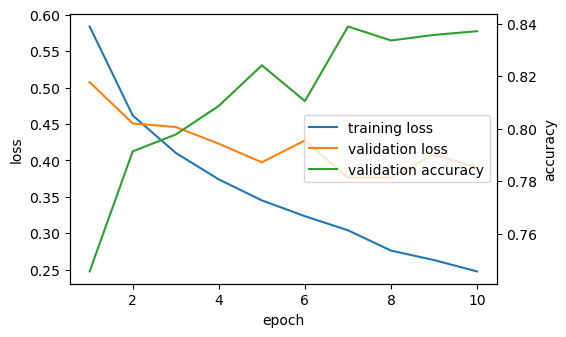

In [13]:
# loss and accuracy live on different scales, so give each its own y-axis
fig, ax1 = plt.subplots(figsize=(5.5, 3.5))
epochs_range = range(1, len(loss_train) + 1)
ax1.plot(epochs_range, loss_train, color='C0', label='training loss')
ax1.plot(epochs_range, loss_valid, color='C1', label='validation loss')
ax1.set_xlabel('epoch')
ax1.set_ylabel('loss')
ax2 = ax1.twinx()
ax2.plot(epochs_range, accuracy_valid, color='C2',
         label='validation accuracy')
ax2.set_ylabel('accuracy')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right');

The learning curves should land where notebook 1's did, up to run-to-run noise.  Note what that means: our model *adds* the positional encoding that notebook 1's model lacked, yet IMDb accuracy barely moves — more evidence that sentiment is largely a bag-of-words task.  The difference is real all the same: unlike notebook 1's model, this one responds to word order (scramble a review and the logits now change; notebook 4, exercise 5 pursues where that matters).  And since our blocks store their attention weights, the peek-inside helper from notebook 1 works here without the library detour:

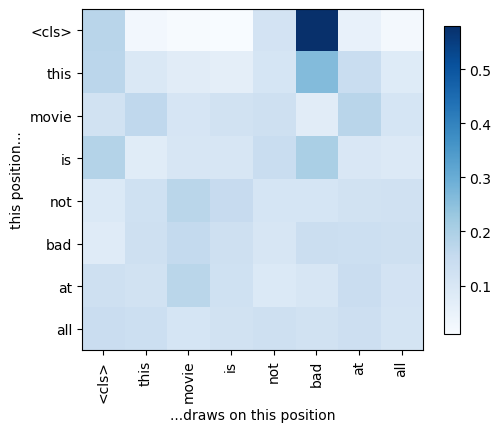

In [15]:
def attention_map(model, text, layer=0):
    """Attention weights of one of our encoder blocks for a piece of text,
    averaged over heads."""
    model.eval()
    tokens = ['<cls>'] + tokenize(text)
    X = torch.tensor(vocab[tokens], device=device).reshape(1, -1)
    with torch.no_grad():
        model(X)
    w = model.blks[layer].attention.attention_weights  # (batch, heads, n, n)
    return tokens, w[0].mean(dim=0).cpu()               # drop batch, avg heads

def show_attention(tokens, weights):
    fig, ax = plt.subplots(figsize=(5.5, 5))
    im = ax.imshow(weights, cmap='Blues')
    ax.set_xticks(range(len(tokens)), tokens, rotation=90)
    ax.set_yticks(range(len(tokens)), tokens)
    ax.set_xlabel('...draws on this position')
    ax.set_ylabel('this position...')
    fig.colorbar(im, shrink=0.8)

tokens, weights = attention_map(model, 'this movie is not bad at all', 1)
show_attention(tokens, weights)

With every component now defined, these maps reward a closer reading than the "rattle the box" peek of notebook 1.  Compare the two layers (`layer=0` and `layer=1`); a pattern that shows up reliably in our runs, and that you should check in yours, is a *division of labor*.  In the first layer, the rows of many positions — not just `<cls>` — concentrate their weight on the evaluative keywords ("bad"): the layer broadcasts the decisive evidence into many positions' vectors, the summary slot among them.  In the second layer the `<cls>` row often attends mostly to *itself*.  That is less strange than it looks: after layer 1 the `<cls>` vector already carries the aggregated evidence, and since the attention output is added to the residual stream, attending to yourself is a way of passing your summary through undisturbed — there is nothing left elsewhere that the classifier still needs.

A caution that belongs in every discussion of attention maps: the weights show where information *can* flow, and they invite readings like the one above, but they are not by themselves a verified explanation of what the model computes — the values being averaged, and everything the FFN does afterward, are invisible in the map.  Treat the story above as a hypothesis that happens to fit; exercise 5 shows a setting where the map's structure can be explained *rigorously*, from gradient flow alone.

## The box, fully open

A closing inventory.  Every name in the black box of notebook 1 now maps to something we built and verified:

| notebook 1 (library) | built and verified in |
|---|---|
| `F.scaled_dot_product_attention` | notebook 3: `attention` |
| `nhead`, `nn.MultiheadAttention` | notebook 4: `MultiHeadAttention` |
| positional encoding (absent from notebook 1's model!) | notebook 4 |
| `dim_feedforward` | this notebook: `PositionWiseFFN` |
| `nn.TransformerEncoderLayer` | this notebook: `TransformerEncoderBlock` |
| `nn.TransformerEncoder` | this notebook: the block stack |

And the three clues from notebook 1 all found their explanations: the all-pairs interaction is the $\mathbf{Q}\mathbf{K}^\top$ matrix product, the row-normalized weights are a softmax, and the order-blindness is permutation equivariance — repaired at the input by the positional encoding.

## Summary

* An encoder block is two sublayers — multi-head self-attention (mixes information *across* positions) and a position-wise FFN (computes nonlinearly *within* each position) — each wrapped in a residual connection and layer normalization.
* **Residual connections**, $\mathbf{x} + \textrm{sublayer}(\mathbf{x})$, change which function is easy rather than which are expressible: the identity becomes $\textrm{sublayer}(\mathbf{x}) = 0$, where small initialization and weight decay already point.  Backward, the Jacobian product picks up a leading $\mathbf{I}$ that no choice of weights can shrink, so gradient reaches every depth through a weight-free path.  The addition also forces every sublayer to preserve $d_{\textrm{model}}$.
* **Layer normalization** standardizes each position's vector across its own features and then applies a learned scale $\boldsymbol{\gamma}$ and shift $\boldsymbol{\beta}$.  Unlike batch normalization it never looks across the batch, so it is unaffected by padding, sequence length and batch size, keeps no running statistics, and computes the same function in training and in generation.
* With weights copied, our block is numerically identical to `nn.TransformerEncoderLayer`, and the assembled from-scratch classifier matches the black-box model's accuracy on IMDb.
* Embeddings are scaled by $\sqrt{d_{\textrm{model}}}$ so the learned content signal is not initially drowned out by the fixed positional encoding.

## Exercises

1. Initialize the embedding layer with pretrained 100-dimensional GloVe vectors (download `glove.6B.100d.txt` from https://nlp.stanford.edu/projects/glove/, build a `vocab`-aligned matrix, and `copy_` it into `model.embedding.weight`; freeze it with `requires_grad = False`).  Does accuracy improve?  Does the model converge faster?  Reconcile with what the RNN module taught about rare words and pretrained embeddings.
2. The original transformer applies layer norm *after* the residual addition (as we did); most modern models apply it *before* the sublayer ("pre-norm", `norm_first=True` in PyTorch).  Modify `TransformerEncoderBlock` into a pre-norm version and verify it against `nn.TransformerEncoderLayer(norm_first=True)`.  Why might pre-norm train more stably in very deep stacks?
3. Our implementation lets every position attend to `<pad>` tokens.  Add a padding mask: set the attention scores toward padding positions to $-10^6$ before the softmax (so their weights vanish), and re-train.  Does it matter here?  Why might it matter more for shorter `num_steps`?
4. Train with `num_blks=4` and half the epochs.  Compare accuracy and overfitting against the 2-block model.
5. **Explain the random map.**  Train a model with `num_blks=1` and plot its attention map: the `<cls>` row looks purposeful, but every other row looks like that of an untrained model (verify this by comparing against one).  Explain the pattern by tracing gradients: with our readout, which outputs of a one-layer model ever influence the loss?  Through which rows of the attention-weight matrix does gradient therefore flow?  What, then, is the one thing the attention mechanism is being trained to do in this regime?  (This is not a contrived setup — single-layer attention classifiers appear in practice, e.g., over DNA sequences in computational biology, and their maps show exactly this structure: noise everywhere except a `<cls>` row that has learned to pick out the relevant tokens.)
6. **Remove the residuals.**  Change `AddNorm.forward` to `return self.ln(self.dropout(Y))`, dropping the `+ X`, and retrain the two-block classifier: the damage is real but survivable.  Then run both versions with `num_blks=8`.  Where does the difference show up, why is it nearly invisible at two blocks, and which curve in the gradient-by-depth plot predicted this?
7. **Normalize the wrong axis.**  Swap the `nn.LayerNorm` inside `AddNorm` for an `nn.BatchNorm1d` over the feature dimension (you will need to transpose, since it expects `(batch, features, positions)`) and retrain.  Then evaluate the same model twice, once in `train()` mode and once in `eval()` mode, and explain the gap.  Finally, predict what would happen if the reviews in a batch were sorted by length rather than shuffled.


different senses: [1.    0.931 0.929]
same sense      : [1.    0.862 0.802]


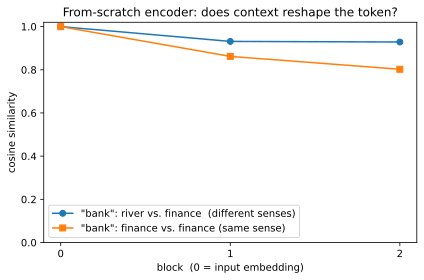

In [26]:
import math, numpy as np, torch
import matplotlib.pyplot as plt

# NEGATIVE CONTROL: the 2-layer, sentiment-only encoder from notebook 6.
# Needs that notebook's objects in scope -- run this there, or %run it in.
if not all(n in globals() for n in ('model', 'vocab', 'tokenize')):
    raise NameError("this cell needs notebook 6's `model`, `vocab`, and "
                    "`tokenize` -- run it in that notebook's namespace")

@torch.no_grad()
def word_layer_vectors_scratch(sentence, word):
    """(num_blks+1, num_hiddens) -- `word`'s vector at each stage of the
    from-scratch encoder: row 0 = input (embedding + positional), then the
    output of each encoder block.  Word-level, so one token per word."""
    model.eval()
    toks = ['<cls>'] + tokenize(sentence)
    if word not in toks:
        raise ValueError(f'"{word}" (lowercased) is not a token in: {sentence!r}')
    if vocab[word] == vocab.unk:
        raise ValueError(f'"{word}" is out-of-vocabulary (<unk>) -- pick a commoner word')
    pos = toks.index(word)
    X = torch.tensor(vocab[toks], device=device).reshape(1, -1)
    H = model.pos_encoding(model.embedding(X) * math.sqrt(model.num_hiddens))
    reps = [H[0, pos]]                      # layer 0: input representation
    for blk in model.blks:
        H = blk(H)
        reps.append(H[0, pos])             # after each encoder block
    return torch.stack(reps).cpu()

def cos_by_layer(a, b):
    return F.cosine_similarity(a, b, dim=1).numpy()

diff = cos_by_layer(
    word_layer_vectors_scratch('i sat on the river bank and watched the water', 'bank'),
    word_layer_vectors_scratch('i deposited a check at the bank downtown',      'bank'))
same = cos_by_layer(
    word_layer_vectors_scratch('i deposited a check at the bank downtown',    'bank'),
    word_layer_vectors_scratch('she withdrew cash from the bank this morning', 'bank'))

print('different senses:', np.round(diff, 3))
print('same sense      :', np.round(same, 3))

plt.figure(figsize=(6, 4))
plt.plot(diff, 'o-', label='"bank": river vs. finance  (different senses)')
plt.plot(same, 's-', label='"bank": finance vs. finance (same sense)')
plt.xlabel('block  (0 = input embedding)'); plt.ylabel('cosine similarity')
plt.xticks(range(len(diff))); plt.ylim(0, 1.02); plt.legend()
plt.title('From-scratch encoder: does context reshape the token?')
plt.tight_layout();